# Лабораторная работа №3: базовая нейросеть и достижение порога качества

Цель: обучить собственный MLP на d1/d2, сравнить Adam и Heavy-Ball, показать
метрики, кривые, матрицы ошибок, границы решений и итоговый F1-блок для d3

## 1. Подготовка окружения

Импорт, переход в корень проекта, seed и стиль графиков

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import optlib
from optlib import datasets, plotting, studies

# Делаем ноутбук независимым от директории запуска: переходим в корень проекта
# (там, где лежит каталог data/), чтобы относительные пути к датасетам работали
# одинаково и при «Run All», и при headless-запуске через nbconvert.
_here = Path.cwd()
for _candidate in (_here, *_here.parents):
    if (_candidate / "data" / "first_dataset.csv").exists():
        os.chdir(_candidate)
        break

plotting.use_notebook_style()

SEED = 42
np.random.seed(SEED)

D1 = "data/first_dataset.csv"  # d1: 2 признака, бинарный таргет
D2 = "data/second_dataset.csv"  # d2: 4 признака, бинарный таргет

print("optlib импортирован, версия ядра доступна через пакет optlib")
print("seed =", SEED)

optlib импортирован, версия ядра доступна через пакет optlib
seed = 42


## 2. Обзор датасетов

d1 и d2 лежат в `data/`: бинарный target, сбалансированные классы, split 80/20
Стандартизация обучается только на train

In [2]:
# Сырые признаки/таргеты для визуализации
X1, y1 = datasets.load_csv(D1)
X2, y2 = datasets.load_csv(D2)

# Стратифицированное разбиение 80/20 + стандартизация (fit на train)
split1 = datasets.load_dataset(D1, test_size=0.2, seed=SEED)
split2 = datasets.load_dataset(D2, test_size=0.2, seed=SEED)


def describe(name: str, X: np.ndarray, y: np.ndarray, split) -> dict:
    y = np.asarray(y).astype(int)
    return {
        "датасет": name,
        "строк": X.shape[0],
        "признаков": X.shape[1],
        "класс 0": int((y == 0).sum()),
        "класс 1": int((y == 1).sum()),
        "train": np.asarray(split.x_train).shape[0],
        "test": np.asarray(split.x_test).shape[0],
    }


overview = pd.DataFrame([describe("d1", X1, y1, split1), describe("d2", X2, y2, split2)]).set_index(
    "датасет"
)
overview

,строк,признаков,класс 0,класс 1,train,test
датасет,,,,,,
d1,600,2,300,300,480,120
d2,600,4,300,300,480,120


d1 рисуем целиком; d2 показываем как 2D-проекцию по первым двум признакам

findfont: Failed to find font weight semibold, now using 700.


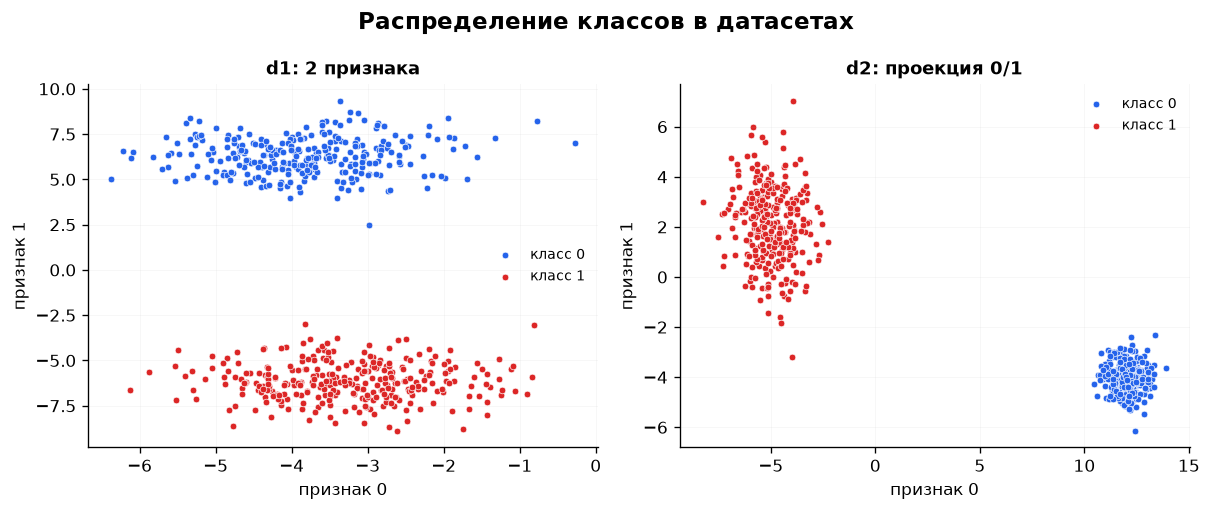

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.3))

for ax, X, y, title in (
    (axes[0], X1, y1, "d1: 2 признака"),
    (axes[1], X2, y2, "d2: проекция 0/1"),
):
    X = np.asarray(X)
    y = np.asarray(y).astype(int)
    for label, color in ((0, "#2563eb"), (1, "#dc2626")):
        mask = y == label
        ax.scatter(
            X[mask, 0],
            X[mask, 1],
            s=16,
            color=color,
            edgecolor="white",
            linewidth=0.4,
            label=f"класс {label}",
        )
    ax.set_xlabel("признак 0")
    ax.set_ylabel("признак 1")
    ax.set_title(title)
    ax.legend()

fig.suptitle("Распределение классов в датасетах", fontsize=14, fontweight="bold")
plt.show()

## 3. Обучение парой оптимизаторов

Пара оптимизаторов: Adam и Heavy-Ball. Архитектура: один скрытый слой `tanh`,
сигмоидный выход и BCE-loss

In [4]:
HIDDEN_DIM = 16
LR = 0.03
MAX_ITER = 4000  # достаточно для уверенной сходимости; финальная модель: 5000

rows = datasets.run_lab3_experiment(
    {"d1": D1, "d2": D2},
    optimizers=("adam", "heavy_ball"),
    hidden_dim=HIDDEN_DIM,
    learning_rate=LR,
    max_iter=MAX_ITER,
    activation="tanh",
    l2=1e-4,
    seed=SEED,
)

results = pd.DataFrame(rows)
metrics_table = (
    results[["dataset", "method", "train_f1", "test_f1", "accuracy", "precision", "recall"]]
    .rename(
        columns={
            "dataset": "датасет",
            "method": "оптимизатор",
            "train_f1": "F1 (train)",
            "test_f1": "F1 (test)",
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
        }
    )
    .set_index(["датасет", "оптимизатор"])
)
metrics_table.style.format("{:.4f}").background_gradient(cmap="Greens", subset=["F1 (test)"])

F1 близок к 1.0 на обоих датасетах. Главное отличие оптимизаторов: скорость
сходимости, а не финальное качество

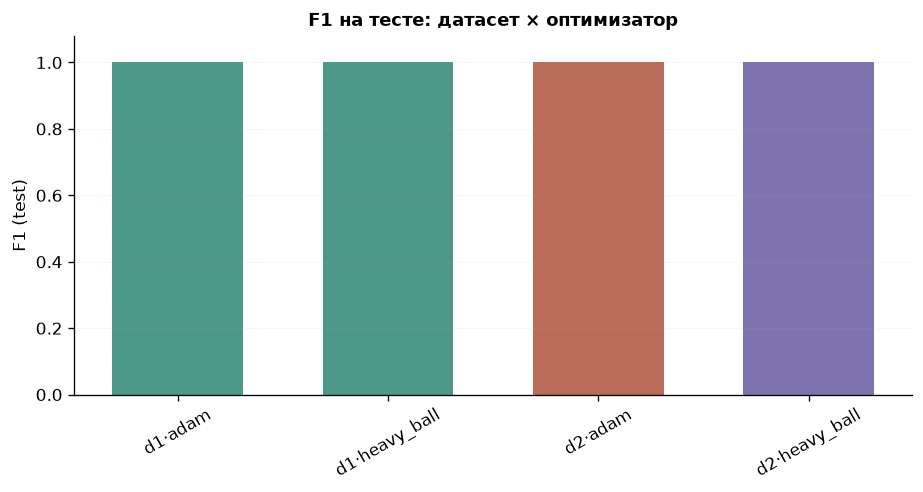

In [5]:
fig, ax = plt.subplots(figsize=(7.8, 4.2))
labels = [f"{r['dataset']}·{r['method']}" for r in rows]
values = [r["test_f1"] for r in rows]
plotting.bar_comparison(
    ax,
    labels,
    values,
    ylabel="F1 (test)",
    title="F1 на тесте: датасет × оптимизатор",
)
ax.set_ylim(0.0, 1.08)
plt.show()

### 3.1. Кривые обучения: loss и F1

Логируем траекторию параметров и считаем F1 на test в контрольных точках

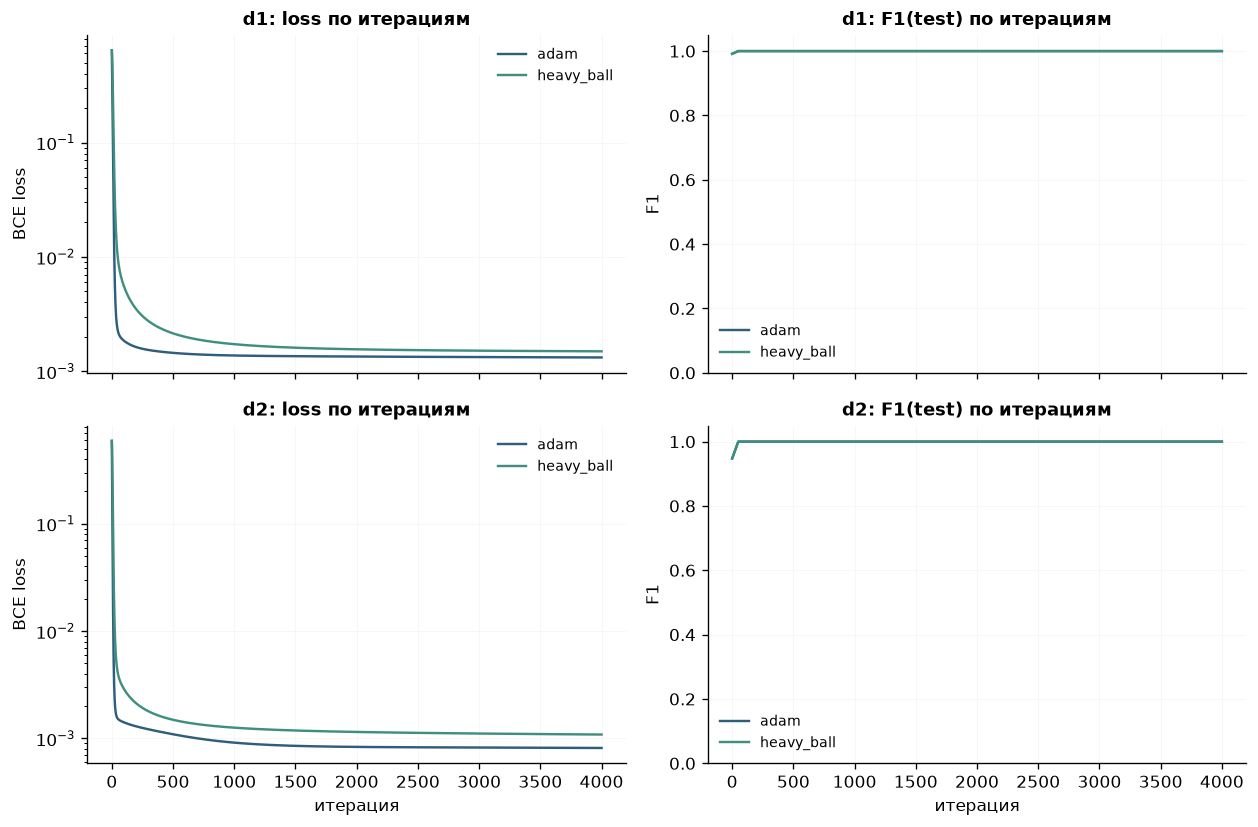

In [6]:
curve_results = {}
for dataset_name, path in (("d1", D1), ("d2", D2)):
    for method in ("adam", "heavy_ball"):
        curve_results[(dataset_name, method)] = datasets.train_binary_dataset(
            path,
            hidden_dim=HIDDEN_DIM,
            method=method,
            learning_rate=LR,
            max_iter=MAX_ITER,
            activation="tanh",
            l2=1e-4,
            seed=SEED,
            log_trajectory=True,
        )


def trajectory_f1(result, checkpoints: int = 80) -> tuple[np.ndarray, np.ndarray]:
    path = np.asarray(result.model.classifier.optimizer_result_["trajectory"]["x"])
    indices = np.unique(
        np.linspace(0, path.shape[0] - 1, min(checkpoints, path.shape[0])).astype(int)
    )
    scores = []
    for index in indices:
        probe = optlib.MLPClassifier(hidden_dim=HIDDEN_DIM, activation="tanh").set_parameters(
            path[index], result.split.x_train.shape[1]
        )
        probabilities = probe.predict_proba(result.split.x_test)
        scores.append(datasets.binary_metrics(result.split.y_test, probabilities)["f1"])
    return indices, np.asarray(scores)


fig, axes = plt.subplots(2, 2, figsize=(10.6, 7.0), sharex="col")
for dataset_index, dataset_name in enumerate(("d1", "d2")):
    for method_index, method in enumerate(("adam", "heavy_ball")):
        result = curve_results[(dataset_name, method)]
        trajectory = result.model.classifier.optimizer_result_["trajectory"]
        loss = np.asarray(trajectory["f"], dtype=float)
        color = plotting.PALETTE[method_index]
        axes[dataset_index, 0].semilogy(loss, color=color, label=method)
        idx, f1_values = trajectory_f1(result)
        axes[dataset_index, 1].plot(idx, f1_values, color=color, label=method)
    axes[dataset_index, 0].set_title(f"{dataset_name}: loss по итерациям")
    axes[dataset_index, 0].set_ylabel("BCE loss")
    axes[dataset_index, 1].set_title(f"{dataset_name}: F1(test) по итерациям")
    axes[dataset_index, 1].set_ylabel("F1")
    axes[dataset_index, 1].set_ylim(0.0, 1.05)
    axes[dataset_index, 0].legend()
    axes[dataset_index, 1].legend()
axes[1, 0].set_xlabel("итерация")
axes[1, 1].set_xlabel("итерация")
plt.show()

## 4. Матрицы ошибок

Матрицы ошибок на test для пары оптимизаторов и обоих датасетов

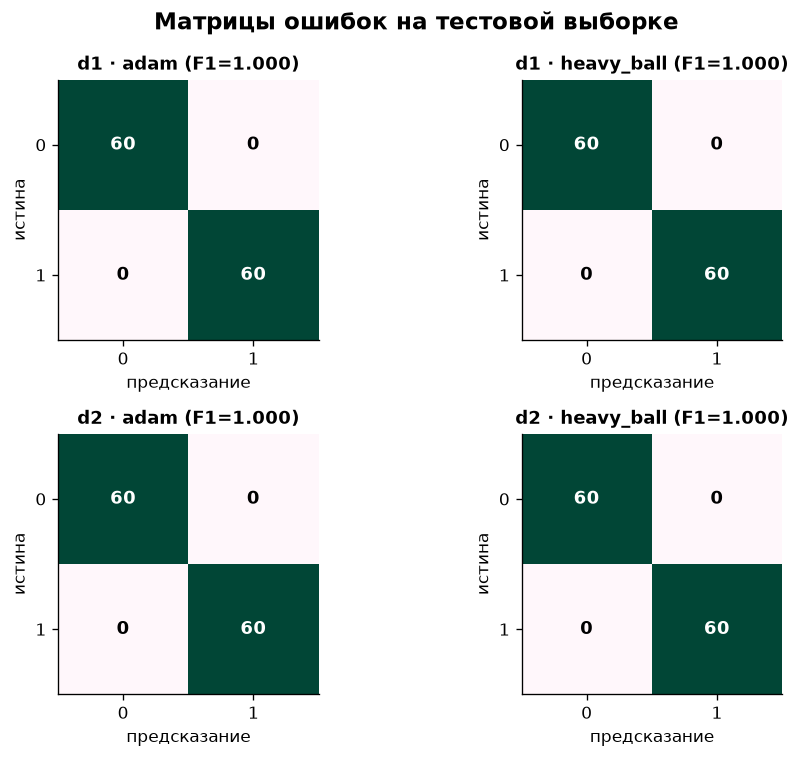

In [7]:
res1 = curve_results[("d1", "adam")]
res2 = curve_results[("d2", "adam")]

fig, axes = plt.subplots(2, 2, figsize=(8.2, 6.4))
for row, dataset_name in enumerate(("d1", "d2")):
    for col, method in enumerate(("adam", "heavy_ball")):
        result = curve_results[(dataset_name, method)]
        plotting.plot_confusion_matrix(
            axes[row, col],
            result.test_metrics["confusion_matrix"],
            labels=("0", "1"),
            title=f"{dataset_name} · {method} (F1={result.test_metrics['f1']:.3f})",
        )
fig.suptitle("Матрицы ошибок на тестовой выборке", fontsize=14, fontweight="bold")
plt.show()

## 5. Границы решений: d1 и 2D-срез d2

d1 рисуем в полном 2D. Для d2 фиксируем признаки 2-3 на среднем raw-значении и
рисуем срез по признакам 0-1. `predict_proba` принимает raw-признаки и сам
применяет сохранённую стандартизацию

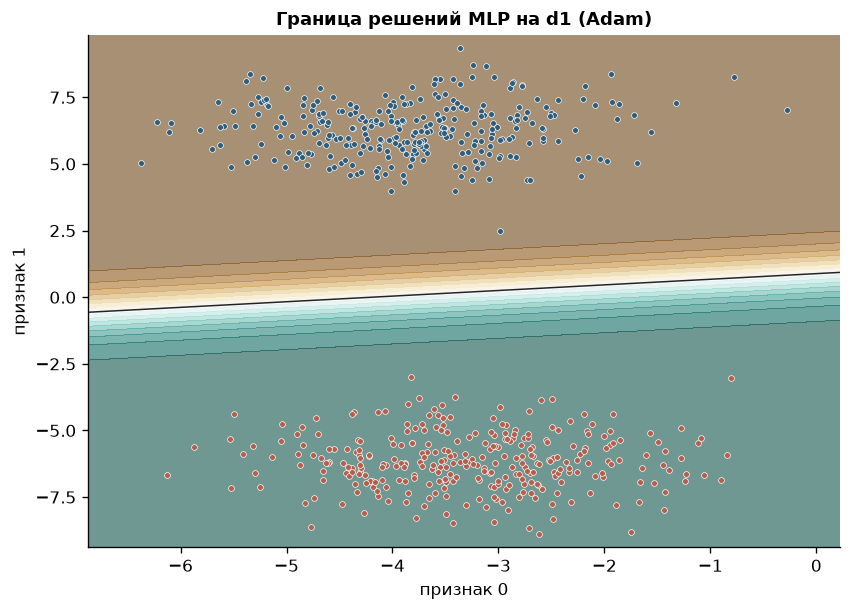

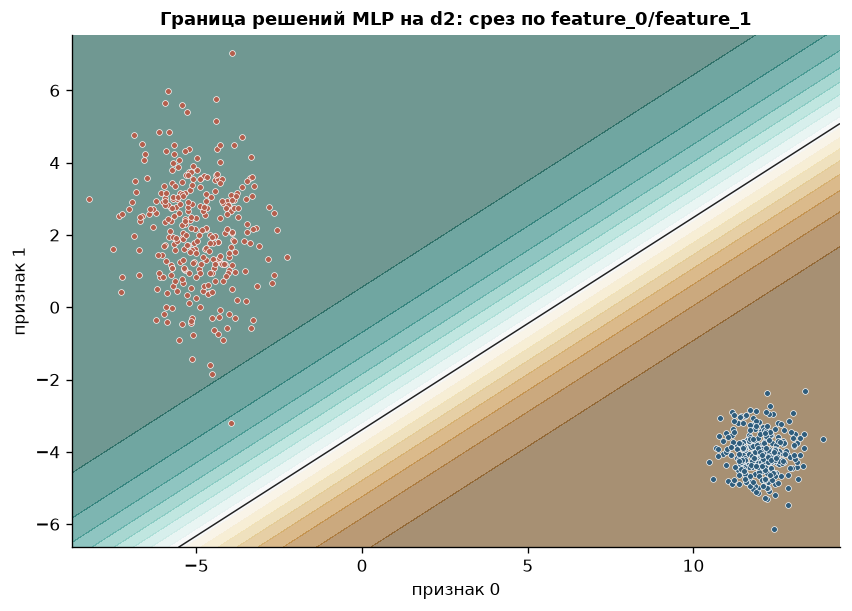

In [8]:
model1 = res1.model  # обучен на d1 с Adam


# predict_proba ждёт RAW-признаки (стандартизация выполняется внутри модели)
def proba_d1(mesh: np.ndarray) -> np.ndarray:
    return np.asarray(model1.predict_proba(mesh)).ravel()


fig, ax = plt.subplots(figsize=(7.2, 5.2))
plotting.plot_decision_boundary(
    ax,
    proba_d1,
    np.asarray(X1),
    np.asarray(y1),
    title="Граница решений MLP на d1 (Adam)",
)
plt.show()

model2 = res2.model
d2_center = np.mean(np.asarray(X2), axis=0)


def proba_d2_slice(mesh: np.ndarray) -> np.ndarray:
    raw = np.tile(d2_center, (mesh.shape[0], 1))
    raw[:, :2] = mesh
    return np.asarray(model2.predict_proba(raw)).ravel()


fig, ax = plt.subplots(figsize=(7.2, 5.2))
plotting.plot_decision_boundary(
    ax,
    proba_d2_slice,
    np.asarray(X2)[:, :2],
    np.asarray(y2),
    title="Граница решений MLP на d2: срез по feature_0/feature_1",
)
plt.show()

## 6. Влияние скорости обучения и ширины скрытого слоя

На d2 варьируем `lr` и `hidden_dim` при коротком бюджете. Trainer работает в
full-batch режиме, поэтому batch size фиксирован размером train split

In [9]:
batch_note = pd.DataFrame(
    [
        {"dataset": "d1", "batch_size": len(split1.x_train)},
        {"dataset": "d2", "batch_size": len(split2.x_train)},
    ]
)
display(batch_note)

sweep_rows = []
for lr in (0.005, 0.01, 0.03, 0.1, 0.3):
    for hd in (8, 16, 32):
        r = datasets.train_binary_dataset(
            D2,
            hidden_dim=hd,
            method="adam",
            learning_rate=lr,
            max_iter=800,
            activation="tanh",
            l2=1e-4,
            seed=SEED,
        )
        sweep_rows.append(
            {
                "lr": lr,
                "hidden_dim": hd,
                "F1 (test)": r.test_metrics["f1"],
                "loss": r.model.classifier.loss_,
            }
        )

sweep = pd.DataFrame(sweep_rows)
loss_pivot = sweep.pivot(index="lr", columns="hidden_dim", values="loss")
print("Итоговый loss (d2, 800 итераций) по сетке lr × hidden_dim:")
loss_pivot.style.format("{:.4f}").background_gradient(cmap="viridis_r")

,dataset,batch_size
0,d1,480
1,d2,480


Итоговый loss (d2, 800 итераций) по сетке lr × hidden_dim:


hidden_dim,8,16,32
lr,,,
0.005000,0.0020,0.0013,0.0011
0.010000,0.0015,0.0011,0.0010
0.030000,0.0013,0.0010,0.0009
0.100000,0.0011,0.0009,0.0008
0.300000,0.0010,0.0008,0.0007


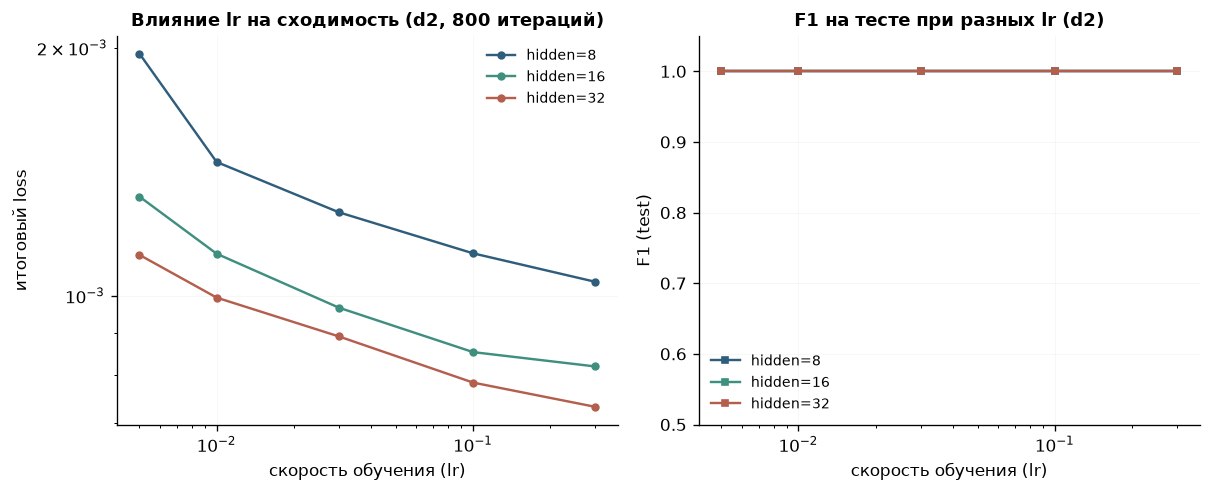

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2))

# (a) loss vs lr для разных hidden_dim
for hd in (8, 16, 32):
    sub = sweep[sweep["hidden_dim"] == hd].sort_values("lr")
    axes[0].plot(sub["lr"], sub["loss"], marker="o", label=f"hidden={hd}")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("скорость обучения (lr)")
axes[0].set_ylabel("итоговый loss")
axes[0].set_title("Влияние lr на сходимость (d2, 800 итераций)")
axes[0].legend()

# (b) F1 vs lr
for hd in (8, 16, 32):
    sub = sweep[sweep["hidden_dim"] == hd].sort_values("lr")
    axes[1].plot(sub["lr"], sub["F1 (test)"], marker="s", label=f"hidden={hd}")
axes[1].set_xscale("log")
axes[1].set_xlabel("скорость обучения (lr)")
axes[1].set_ylabel("F1 (test)")
axes[1].set_ylim(0.5, 1.05)
axes[1].set_title("F1 на тесте при разных lr (d2)")
axes[1].legend()

plt.show()

**Вывод.** Лучший диапазон `lr`: примерно `0.03-0.1`. Ширина слоя влияет слабее:
даже компактная сеть решает задачу

## 7. Итоговая взвешенная метрика F1 (с заделом под d3)

Формула зачётной метрики:

$$
\operatorname{score}=0.3F_1(d_1)+0.3F_1(d_2)+0.4F_1(d_3)
$$

Порог: `0.55`. Сейчас считается d1+d2; на защите достаточно задать `D3_PATH`
Если d3 совместим с binary-моделью, сработает live-evaluate; иначе используется
fallback `weighted_f1_score`

In [11]:
from pathlib import Path

# --- Конфигурация итоговой оценки --------------------------------------------
WEIGHTS = {"d1": 0.3, "d2": 0.3, "d3": 0.4}
THRESHOLD = 0.55
BEST = dict(
    hidden_dim=16,
    method="adam",
    learning_rate=0.03,
    max_iter=5000,
    activation="tanh",
    initialization="xavier",
    l2=1e-4,
    seed=42,
)

# === d3: на защите укажите путь к закрытому датасету ИЛИ скачайте по id Drive ==
#   D3_PATH = "data/third_dataset.csv"
#   или: D3_PATH = optlib.datasets.download("<gdrive_id>", "data/third_dataset.csv")
D3_PATH = None

score = studies.weighted_f1_score({"d1": D1, "d2": D2, "d3": D3_PATH}, weights=WEIGHTS, **BEST)
score_table = pd.DataFrame(score["rows"])
display(
    score_table[["dataset", "mode", "class_count", "weight", "test_f1", "contribution"]]
    .rename(columns={"dataset": "датасет", "test_f1": "F1", "contribution": "вклад"})
    .set_index("датасет")
    .style.format({"weight": "{:.2f}", "F1": "{:.4f}", "вклад": "{:.4f}"})
)

print(f"Итоговый взвешенный F1 = {score['total']:.4f}   (порог {THRESHOLD})")
print("Статус:", "ПРОЙДЕНО (PASS)" if score["total"] >= THRESHOLD else "НЕ ПРОЙДЕНО (FAIL)")
if score["missing"]:
    print("Пока отсутствуют датасеты:", ", ".join(score["missing"]))

# Сохраняем и сразу проверяем live evaluate для совместимого d3-сценария.
Path("artifacts").mkdir(exist_ok=True)
model_path = datasets.train_binary_dataset(D1, **BEST).model.save("artifacts/lab3_model_d1.npz")
loaded = datasets.load_binary_dataset_model(model_path)
check = loaded.evaluate_path(D1)
print(f"Сохранённая модель: {model_path}; self-check на d1 F1={check['f1']:.4f}")

if D3_PATH and Path(D3_PATH).exists():
    try:
        live = loaded.evaluate_path(D3_PATH)
        print(f"Live evaluate сохранённой binary-модели на d3: F1={live['f1']:.4f}")
    except ValueError as exc:
        print("Сохранённая binary-модель несовместима с d3:", exc)
        print(
            "Для такого d3 используется fallback studies.weighted_f1_score с автоопределением классов."
        )

,mode,class_count,weight,F1,вклад
датасет,,,,,
d1,binary,2,0.30,1.0000,0.3000
d2,binary,2,0.30,1.0000,0.3000


Итоговый взвешенный F1 = 0.6000   (порог 0.55)
Статус: ПРОЙДЕНО (PASS)
Пока отсутствуют датасеты: d3


Сохранённая модель: artifacts\lab3_model_d1.npz; self-check на d1 F1=1.0000


## Выводы

1. Собственный MLP решает d1/d2 с F1 около 1.0
2. Adam и Heavy-Ball дают близкое качество; различаются в скорости
3. Оптимальный рабочий диапазон `lr`: `0.03-0.1`
4. Итоговая ячейка готова к d3: compatible binary live-evaluate или OVR fallback
5. Финальный конфиг: `hidden_dim=16`, `adam`, `lr=0.03`, `max_iter=5000`,
   `activation=tanh`, `l2=1e-4`